# Traditional-method reproduction and analysis

This notebook analyses the teammates' saved predictions alongside locally reproduced predictions. It does **not** start training. The original implementation under `src/traditional/` remains unchanged.

Dataset: 500 species, 40 training + 10 validation + 10 held-out test images per species, seed 0.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

start = Path.cwd().resolve()
WORKSPACE = next((candidate for candidate in (start, *start.parents) if (candidate / 'reproduction').is_dir() and (candidate / 'src').is_dir()), None)
if WORKSPACE is None:
    raise RuntimeError('Could not locate the COMP9517 workspace from the current directory.')

ANALYSIS = WORKSPACE / 'reproduction' / 'outputs' / 'traditional' / 'analysis_v1'
TEAMMATE_PREDICTIONS = WORKSPACE / 'src' / 'traditional' / 'results' / 'predictions'
REPRODUCED_PREDICTIONS = WORKSPACE / 'reproduction' / 'outputs' / 'traditional' / 'baseline_500_seed0_run01' / 'results' / 'predictions'
DATA_ROOT = WORKSPACE / 'data' / 'inat2021' / 'reproduced' / 'sampled_500'

for required in (ANALYSIS, TEAMMATE_PREDICTIONS, REPRODUCED_PREDICTIONS, DATA_ROOT):
    assert required.exists(), f'Missing required path: {required}'
print('Workspace:', WORKSPACE)
print('Analysis:', ANALYSIS)

Workspace: C:\Users\17111\COMP9517GROUP_SUBJECT
Analysis: C:\Users\17111\COMP9517GROUP_SUBJECT\reproduction\outputs\traditional\analysis_v1


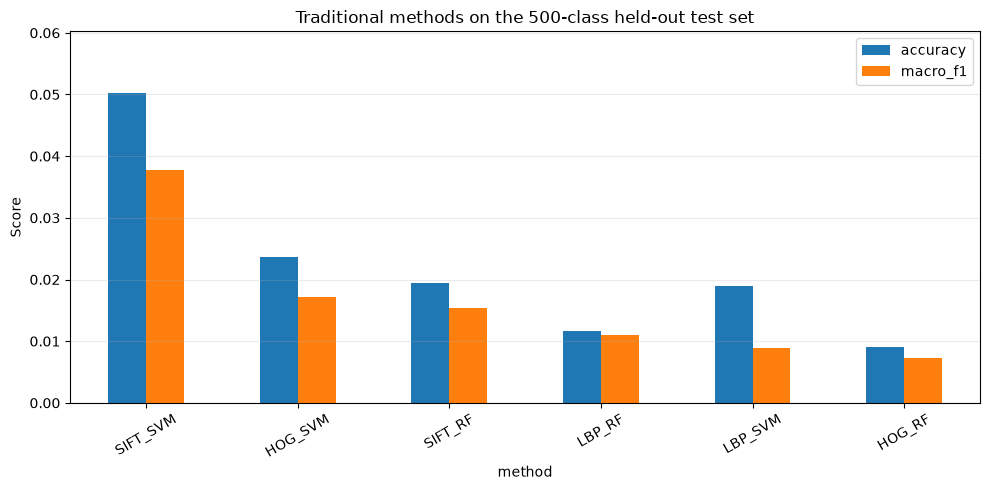

In [3]:
teammate = metrics[metrics['source'] == 'teammate'].copy().sort_values('macro_f1', ascending=False)
ax = teammate.set_index('method')[['accuracy', 'macro_f1']].plot.bar(figsize=(10, 5), rot=30)
ax.set_title('Traditional methods on the 500-class held-out test set')
ax.set_ylabel('Score')
ax.set_ylim(0, max(0.06, teammate[['accuracy', 'macro_f1']].to_numpy().max() * 1.2))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 2. Reproduction agreement

Prediction agreement is stricter than matching aggregate accuracy: it checks whether both runs predicted the same label for each individual test image.

In [4]:
comparisons = pd.DataFrame(json.loads((ANALYSIS / 'comparisons.json').read_text(encoding='utf-8')))
comparison_display = comparisons.copy()
comparison_display['prediction_agreement'] = comparison_display['prediction_agreement'].map(lambda value: f'{value:.2%}' if pd.notna(value) else 'N/A')
display(comparison_display)

AttributeError: The '.style' accessor requires jinja2

Interpretation:

- HOG-SVM matching 100% is strong evidence that the dataset, ordering, features, and classifier settings were reproduced.
- LBP-SVM matching approximately 99.94% is effectively reproduced, with only a few prediction differences.
- Random Forest differences require investigation; aggregate metrics alone should not be described as exact reproduction.

## 3. Per-class performance and hardest confusions

In [ ]:
METHOD = 'SIFT_SVM'
method_dir = ANALYSIS / 'teammate' / METHOD
per_class = pd.read_csv(method_dir / 'per_class_metrics.csv')
hardest = pd.read_csv(method_dir / 'hardest_confusions.csv')

print(f'{METHOD}: lowest-F1 classes')
display(per_class.sort_values(['f1', 'recall']).head(15).round(4))
print(f'{METHOD}: most frequent directed confusions')
display(hardest.head(15))

In [ ]:
labels = np.load(method_dir / 'labels.npy')
cm = np.load(method_dir / 'confusion_matrix.npy')
errors = cm.sum(axis=1) - np.diag(cm)
selected_indices = np.argsort(errors)[-30:]
selected_cm = cm[np.ix_(selected_indices, selected_indices)]
selected_labels = labels[selected_indices]

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(selected_cm, cmap='magma')
ax.set_title(f'{METHOD}: confusion matrix among 30 high-error classes')
ax.set_xlabel('Predicted category ID')
ax.set_ylabel('True category ID')
ax.set_xticks(range(len(selected_labels)), selected_labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(selected_labels)), selected_labels, fontsize=7)
fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 4. Representative SIFT-SVM errors

In [ ]:
dataset = json.loads((DATA_ROOT / 'val.json').read_text(encoding='utf-8'))
image_by_id = {image['id']: image for image in dataset['images']}
label_by_image = {annotation['image_id']: annotation['category_id'] for annotation in dataset['annotations']}
ordered_images = [image for image in dataset['images'] if image['id'] in label_by_image]
names = {category['id']: category.get('name', category['image_dir_name']) for category in dataset['categories']}
y_true = np.load(TEAMMATE_PREDICTIONS / 'SIFT_SVM_y_true.npy')
y_pred = np.load(TEAMMATE_PREDICTIONS / 'SIFT_SVM_y_pred.npy')
error_indices = np.flatnonzero(y_true != y_pred)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, index in zip(axes.flat, error_indices):
    record = ordered_images[int(index)]
    path = DATA_ROOT / record['file_name']
    ax.imshow(Image.open(path).convert('RGB'))
    ax.set_title(f"True: {names[int(y_true[index])]}\nPred: {names[int(y_pred[index])]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Reproduction status

- Locally completed: HOG-SVM, HOG-RF, LBP-SVM, LBP-RF.
- Teammate predictions available: all six methods, including SIFT-SVM and SIFT-RF.
- Exact SIFT retraining remains pending.
- Correct Top-5 remains unavailable until a model or per-class score matrix is produced.
- Trained artifacts are local analysis files and must not be included in the final 40 MB code submission.